# **Proyek Fuzzy Logic: Segmentasi Potensi Ekonomi** - by Rozhak

Notebook ini merupakan implementasi lengkap dari Fuzzy Inference System (FIS) untuk mengklasifikasikan potensi ekonomi kabupaten/kota di Sulawesi Tenggara. Proyek ini mencakup seluruh tahapan, mulai dari pra-pemrosesan data hingga analisis perbandingan antara metode Mamdani dan Sugeno.

## **1. Pengaturan Proyek (Project Setup)**

Pada tahap awal ini, kita akan menyiapkan environment kerja dengan menginstal dan mengimpor semua library yang dibutuhkan untuk analisis data, logika fuzzy, dan visualisasi.

In [258]:
!pip install pandas numpy scikit-fuzzy matplotlib seaborn > /dev/null

In [259]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import skfuzzy as fuzz
from skfuzzy import control as ctrl

print("Library berhasil di-import.")

Library berhasil di-import.


## **2. Pra-pemrosesan dan Eksplorasi Data (Data Preprocessing & EDA)**

Tujuan dari tahap ini adalah untuk membersihkan dan menyiapkan dataset agar siap digunakan untuk pemodelan fuzzy.

### **2.1. Memuat Dataset Mentah**

Kita mulai dengan memuat data awal yang berisi berbagai indikator sosio-ekonomi.

In [260]:
try:
    file_path = '/content/raw_data_segmentasi_ekonomi.csv'
    df = pd.read_csv(file_path)
    print("Dataset awal berhasil dimuat.")
except FileNotFoundError:
    print(f"Error: File '{file_path}' tidak ditemukan.")
    print("Pastikan file tersebut sudah diunggah ke environment Colab/Jupyter Anda.")
    raise

display(df.head())

Dataset awal berhasil dimuat.


,Kabupaten/Kota,Jumlah Penduduk,Angka Harapan Hidup,Jumlah yang Masih Sekolah,Tingkat Partisipasi Angkatan Kerja (TPAK),Pengeluaran per Kapita Disesuaikan (Ribu Rupiah),Akses Air Minum Layak,Jumlah Penduduk Miskin,Indeks Pembangunan Manusia,Tingkat Pengangguran Terbuka (TPT),Sejahtera / Tidak Sejahtera
0,Buton,118410,68.46,79.14,77.34,7594,98.53,13.61,67.23,2.99,1
1,Muna,221370,70.47,79.73,66.41,8328,96.10,30.48,69.61,3.11,0
2,Konawe,264930,70.38,69.94,66.81,10552,86.26,32.09,72.04,2.73,0
3,Kolaka,243040,71.30,68.20,64.49,12639,97.68,31.56,73.98,4.17,0
4,Konawe Selatan,318350,70.95,68.82,69.46,9347,89.75,35.79,69.36,2.95,0


### **2.2. Menambahkan Data UMK (Enrichment)**

Dataset awal tidak memiliki data UMK. Kita akan memperkaya data dengan menambahkan informasi UMK 2025.

In [261]:
ump_sultra_2025 = 3073551
umk_spesifik_2025 = {
    'Kabupaten Konawe Utara': 3259583,
    'Kota Kendari': 3314389,
    'Kabupaten Kolaka': 3342626
}
print(f"Data UMK 2025 disiapkan. UMP Sultra: Rp {ump_sultra_2025:,.0f}")

def get_umk(nama_kabupaten):
    """Mencari nilai UMK spesifik, jika tidak ada, kembalikan nilai UMP."""
    for nama_kota, nilai_umk in umk_spesifik_2025.items():
        if nama_kota.split(' ')[1].lower() in nama_kabupaten.lower():
            return nilai_umk
    return ump_sultra_2025

df['UMK_2025'] = df['Kabupaten/Kota'].apply(get_umk)
print("\nKolom 'UMK_2025' berhasil ditambahkan.")

display(df[['Kabupaten/Kota', 'UMK_2025']].head())

Data UMK 2025 disiapkan. UMP Sultra: Rp 3,073,551

Kolom 'UMK_2025' berhasil ditambahkan.


,Kabupaten/Kota,UMK_2025
0,Buton,3073551
1,Muna,3073551
2,Konawe,3259583
3,Kolaka,3342626
4,Konawe Selatan,3259583


### **2.3. Seleksi Fitur dan Pembersihan Kolom**

Kita memilih variabel-variabel yang akan digunakan sebagai input model fuzzy dan merapikan nama kolomnya.

In [262]:
kolom_relevan = {
    'Kabupaten/Kota': 'kabupaten_kota',
    'UMK_2025': 'umk',
    'Jumlah Penduduk': 'jumlah_penduduk',
    'Indeks Pembangunan Manusia': 'ipm',
    'Tingkat Pengangguran Terbuka (TPT)': 'tpt'
}

df_clean = df[list(kolom_relevan.keys())].copy()
df_clean.rename(columns=kolom_relevan, inplace=True)

for col in ['umk', 'jumlah_penduduk', 'ipm', 'tpt']:
    df_clean[col] = pd.to_numeric(df_clean[col])

print("Kolom telah dipilih, dibersihkan, dan dirapikan namanya.")
display(df_clean.head())

Kolom telah dipilih, dibersihkan, dan dirapikan namanya.


,kabupaten_kota,umk,jumlah_penduduk,ipm,tpt
0,Buton,3073551,118410,67.23,2.99
1,Muna,3073551,221370,69.61,3.11
2,Konawe,3259583,264930,72.04,2.73
3,Kolaka,3342626,243040,73.98,4.17
4,Konawe Selatan,3259583,318350,69.36,2.95


### **2.4. Eksplorasi Data Sederhana (EDA)**

Melihat statistik deskriptif untuk memahami rentang dan distribusi data.

In [263]:
print("Informasi Dataset Bersih:")
df_clean.info()

print("\nStatistik Deskriptif:")
display(df_clean.describe().style.format({
    'umk': '{:,.0f}',
    'jumlah_penduduk': '{:,.0f}',
    'ipm': '{:.2f}',
    'tpt': '{:.2f}'
}))

Informasi Dataset Bersih:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   kabupaten_kota   17 non-null     object 
 1   umk              17 non-null     int64  
 2   jumlah_penduduk  17 non-null     int64  
 3   ipm              17 non-null     float64
 4   tpt              17 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 812.0+ bytes

Statistik Deskriptif:


,umk,jumlah_penduduk,ipm,tpt
count,17,17,17.00,17.00
mean,"3,178,974","159,094",70.23,3.05
std,"118,506","91,289",4.78,1.13
min,"3,073,551","38,310",65.29,1.47
25%,"3,073,551","97,950",66.81,2.22
50%,"3,073,551","123,980",69.36,2.86
75%,"3,259,583","221,370",71.10,3.53
max,"3,342,626","357,650",84.51,5.39


### **2.5. Menyimpan Dataset Bersih**

Langkah terakhir dari pra-pemrosesan adalah menyimpan data yang sudah bersih agar bisa digunakan kembali tanpa mengulang proses dari awal.

In [264]:
try:
    output_filename = 'cleaned_data_segmentasi_ekonomi.csv'
    df_clean.to_csv(output_filename, index=False)
    print(f"Proses pra-pemrosesan selesai! Dataset bersih berhasil disimpan sebagai '{output_filename}'")
except Exception as e:
    print(f"Terjadi error saat menyimpan file: {e}")
    raise

Proses pra-pemrosesan selesai! Dataset bersih berhasil disimpan sebagai 'cleaned_data_segmentasi_ekonomi.csv'


## **3. Perancangan Fuzzy Inference System (FIS)**

Ini adalah inti dari proyek, di mana kita mendesain "otak" dari sistem cerdas.

### **3.1. Menentukan Semesta Pembicaraan (Universe of Discourse)**

Menentukan rentang nilai minimum dan maksimum untuk setiap variabel input dan output.

In [265]:
stats = df_clean.describe()

umk_universe = np.arange(stats['umk'].min() * 0.95, stats['umk'].max() * 1.05, 1000)
penduduk_universe = np.arange(stats['jumlah_penduduk'].min() * 0.95, stats['jumlah_penduduk'].max() * 1.05, 100)
ipm_universe = np.arange(stats['ipm'].min() * 0.95, stats['ipm'].max() * 1.05, 0.1)
tpt_universe = np.arange(stats['tpt'].min() * 0.95, stats['tpt'].max() * 1.05, 0.1)

potensi_universe = np.arange(0, 101, 1)
print("Rentang nilai (Universe) untuk semua variabel berhasil didefinisikan.")

Rentang nilai (Universe) untuk semua variabel berhasil didefinisikan.


### **3.2. Fuzzifikasi (Merancang Fungsi Keanggotaan)**

Mendefinisikan himpunan fuzzy (misal: `rendah`, `sedang`, `tinggi`) dan memetakannya ke dalam fungsi keanggotaan.

In [266]:
umk = ctrl.Antecedent(umk_universe, 'umk')
penduduk = ctrl.Antecedent(penduduk_universe, 'jumlah_penduduk')
ipm = ctrl.Antecedent(ipm_universe, 'ipm')
tpt = ctrl.Antecedent(tpt_universe, 'tpt')

potensi = ctrl.Consequent(potensi_universe, 'potensi_ekonomi')

In [267]:
umk['rendah'] = fuzz.trapmf(umk.universe, [umk_universe.min(), umk_universe.min(), 3.1e6, 3.2e6])
umk['sedang'] = fuzz.trimf(umk.universe, [3.1e6, 3.2e6, 3.3e6])
umk['tinggi'] = fuzz.trapmf(umk.universe, [3.2e6, 3.3e6, umk_universe.max(), umk_universe.max()])

penduduk['sedikit'] = fuzz.trapmf(penduduk.universe, [penduduk_universe.min(), penduduk_universe.min(), 100000, 200000])
penduduk['sedang'] = fuzz.trimf(penduduk.universe, [100000, 200000, 300000])
penduduk['banyak'] = fuzz.trapmf(penduduk.universe, [200000, 300000, penduduk_universe.max(), penduduk_universe.max()])

ipm['rendah'] = fuzz.trapmf(ipm.universe, [ipm_universe.min(), ipm_universe.min(), 68, 72])
ipm['sedang'] = fuzz.trimf(ipm.universe, [68, 72, 78])
ipm['tinggi'] = fuzz.trapmf(ipm.universe, [72, 78, ipm_universe.max(), ipm_universe.max()])

tpt['rendah'] = fuzz.trapmf(tpt.universe, [tpt_universe.min(), tpt_universe.min(), 2.5, 3.5])
tpt['sedang'] = fuzz.trimf(tpt.universe, [2.5, 3.5, 4.5])
tpt['tinggi'] = fuzz.trapmf(tpt.universe, [3.5, 4.5, tpt_universe.max(), tpt_universe.max()])

potensi['rendah'] = fuzz.trapmf(potensi.universe, [0, 0, 40, 60])
potensi['sedang'] = fuzz.trimf(potensi.universe, [40, 60, 80])
potensi['tinggi'] = fuzz.trapmf(potensi.universe, [60, 80, 100, 100])

print("Fungsi keanggotaan untuk semua variabel berhasil dibuat.")

Fungsi keanggotaan untuk semua variabel berhasil dibuat.


#### **3.2.1. Visualisasi Fungsi Keanggotaan**



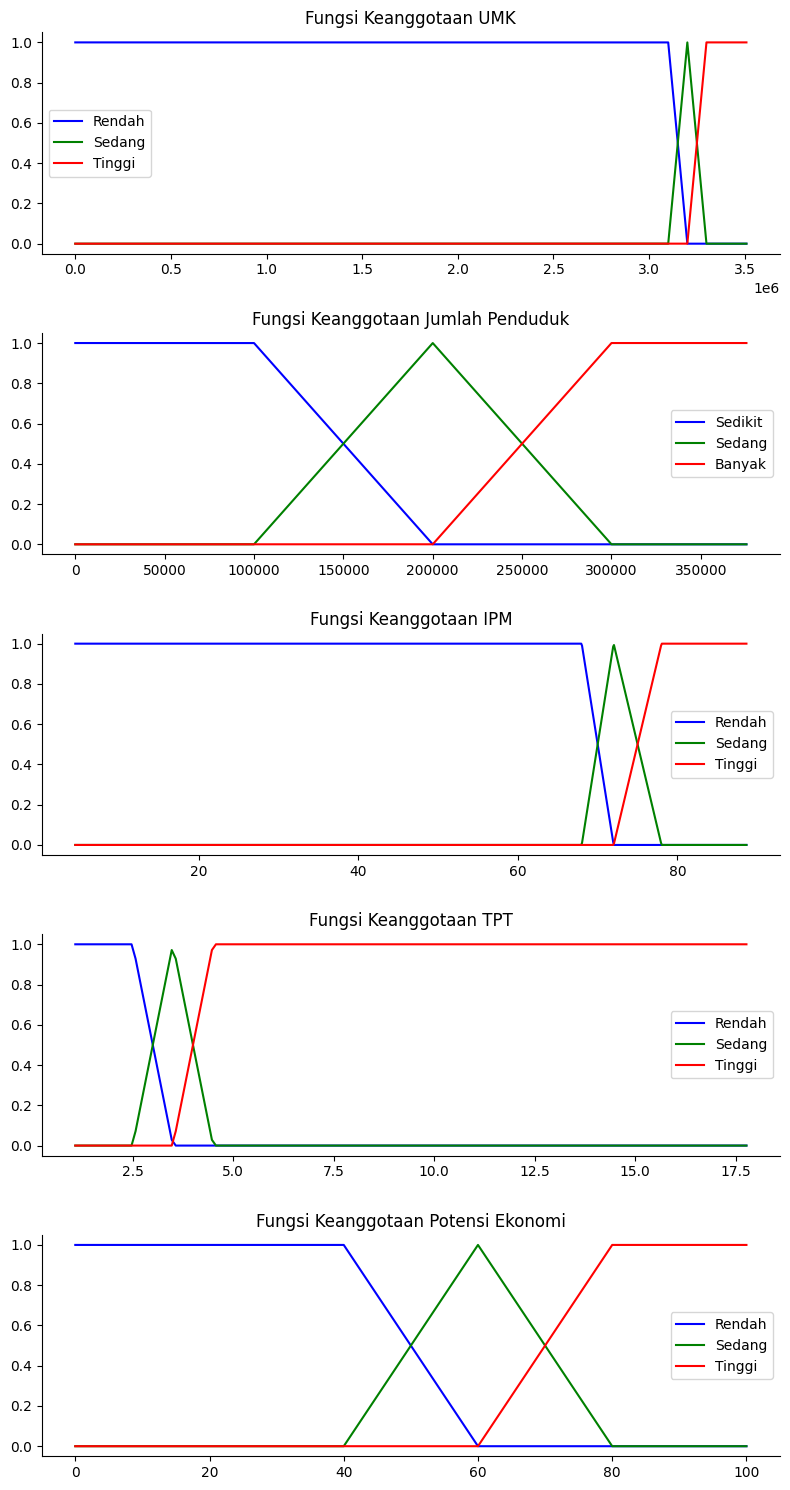

In [268]:
fig, (ax0, ax1, ax2, ax3, ax4) = plt.subplots(nrows=5, figsize=(8, 15))

ax0.plot(umk_universe, umk['rendah'].mf, 'b', linewidth=1.5, label='Rendah')
ax0.plot(umk_universe, umk['sedang'].mf, 'g', linewidth=1.5, label='Sedang')
ax0.plot(umk_universe, umk['tinggi'].mf, 'r', linewidth=1.5, label='Tinggi')
ax0.set_title('Fungsi Keanggotaan UMK')
ax0.legend()

ax1.plot(penduduk_universe, penduduk['sedikit'].mf, 'b', linewidth=1.5, label='Sedikit')
ax1.plot(penduduk_universe, penduduk['sedang'].mf, 'g', linewidth=1.5, label='Sedang')
ax1.plot(penduduk_universe, penduduk['banyak'].mf, 'r', linewidth=1.5, label='Banyak')
ax1.set_title('Fungsi Keanggotaan Jumlah Penduduk')
ax1.legend()

ax2.plot(ipm_universe, ipm['rendah'].mf, 'b', linewidth=1.5, label='Rendah')
ax2.plot(ipm_universe, ipm['sedang'].mf, 'g', linewidth=1.5, label='Sedang')
ax2.plot(ipm_universe, ipm['tinggi'].mf, 'r', linewidth=1.5, label='Tinggi')
ax2.set_title('Fungsi Keanggotaan IPM')
ax2.legend()

ax3.plot(tpt_universe, tpt['rendah'].mf, 'b', linewidth=1.5, label='Rendah')
ax3.plot(tpt_universe, tpt['sedang'].mf, 'g', linewidth=1.5, label='Sedang')
ax3.plot(tpt_universe, tpt['tinggi'].mf, 'r', linewidth=1.5, label='Tinggi')
ax3.set_title('Fungsi Keanggotaan TPT')
ax3.legend()

ax4.plot(potensi_universe, potensi['rendah'].mf, 'b', linewidth=1.5, label='Rendah')
ax4.plot(potensi_universe, potensi['sedang'].mf, 'g', linewidth=1.5, label='Sedang')
ax4.plot(potensi_universe, potensi['tinggi'].mf, 'r', linewidth=1.5, label='Tinggi')
ax4.set_title('Fungsi Keanggotaan Potensi Ekonomi')
ax4.legend()

for ax in [ax0, ax1, ax2, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()
plt.show()

### **3.3. Membuat Aturan Fuzzy (Rule Base)**

Mendefinisikan "pengetahuan" atau logika sistem dalam bentuk aturan `IF-THEN`.

In [269]:
rule01 = ctrl.Rule(ipm['tinggi'] & umk['tinggi'] & tpt['rendah'], potensi['tinggi'])
rule02 = ctrl.Rule(ipm['rendah'] & umk['rendah'] & tpt['tinggi'], potensi['rendah'])
rule03 = ctrl.Rule(ipm['sedang'] & umk['sedang'], potensi['sedang'])
rule04 = ctrl.Rule(tpt['tinggi'], potensi['rendah'])
rule05 = ctrl.Rule(umk['rendah'] & ipm['rendah'], potensi['rendah'])
rule06 = ctrl.Rule(umk['tinggi'] & ipm['tinggi'], potensi['tinggi'])
rule07 = ctrl.Rule(penduduk['banyak'] & ipm['tinggi'], potensi['tinggi'])
rule08 = ctrl.Rule(penduduk['sedikit'] & umk['rendah'], potensi['rendah'])
rule09 = ctrl.Rule(tpt['rendah'] & ipm['sedang'], potensi['sedang'])
rule10 = ctrl.Rule(ipm['tinggi'] & tpt['sedang'], potensi['sedang'])
rule11 = ctrl.Rule(umk['sedang'] & penduduk['sedang'] & ipm['sedang'] & tpt['sedang'], potensi['sedang'])
rule12 = ctrl.Rule(umk['tinggi'] & tpt['tinggi'], potensi['sedang'])
rule13 = ctrl.Rule(ipm['rendah'] & tpt['rendah'], potensi['sedang'])
rule14 = ctrl.Rule(penduduk['banyak'], potensi['sedang'])
rule15 = ctrl.Rule(ipm['tinggi'], potensi['tinggi'])

print("15 aturan fuzzy berhasil dibuat.")

15 aturan fuzzy berhasil dibuat.


### **3.4. Membangun Sistem Kontrol Inferensi (Mamdani)**

Menggabungkan semua aturan ke dalam satu sistem kontrol Mamdani.

In [270]:
potensi_ctrl = ctrl.ControlSystem([rule01, rule02, rule03, rule04, rule05, rule06, rule07, rule08, rule09, rule10, rule11, rule12, rule13, rule14, rule15])

potensi_simulator_mamdani = ctrl.ControlSystemSimulation(potensi_ctrl)

print("Sistem Kontrol Inferensi (Mamdani) berhasil dibangun dan siap digunakan.")

Sistem Kontrol Inferensi (Mamdani) berhasil dibangun dan siap digunakan.


## **4. Implementasi dan Pengujian Sistem (Mamdani)**

Pada tahap ini, kita akan mengaplikasikan sistem Mamdani yang telah dirancang ke seluruh dataset.

### **4.1. Komputasi Skor Potensi**

Looping melalui setiap baris data untuk menghitung skor potensi ekonomi.

In [271]:
hasil_potensi = []

for index, row in df_clean.iterrows():
    potensi_simulator_mamdani.input['umk'] = row['umk']
    potensi_simulator_mamdani.input['jumlah_penduduk'] = row['jumlah_penduduk']
    potensi_simulator_mamdani.input['ipm'] = row['ipm']
    potensi_simulator_mamdani.input['tpt'] = row['tpt']

    potensi_simulator_mamdani.compute()

    hasil_potensi.append(potensi_simulator_mamdani.output['potensi_ekonomi'])

df_clean['skor_mamdani'] = hasil_potensi
print("Komputasi Fuzzy (Mamdani) untuk seluruh dataset selesai.")

Komputasi Fuzzy (Mamdani) untuk seluruh dataset selesai.


### **4.2. Klasifikasi Hasil**

Menerjemahkan skor numerik menjadi kategori linguistik (Rendah, Sedang, Tinggi).

In [272]:
def klasifikasi_potensi(skor):
    if skor <= 50:
        return 'Rendah'
    elif 50 < skor <= 70:
        return 'Sedang'
    else:
        return 'Tinggi'

df_clean['klasifikasi_mamdani'] = df_clean['skor_mamdani'].apply(klasifikasi_potensi)
print("Klasifikasi potensi (Mamdani) berhasil dibuat.")

hasil_akhir_mamdani = df_clean[['kabupaten_kota', 'skor_mamdani', 'klasifikasi_mamdani']].sort_values(by='skor_mamdani', ascending=False)

print("\n------------ [HASIL AKHIR (METODE MAMDANI)] ------------")
display(hasil_akhir_mamdani.style.format({'skor_mamdani': '{:.2f}'}))

Klasifikasi potensi (Mamdani) berhasil dibuat.

------------ [HASIL AKHIR (METODE MAMDANI)] ------------


,kabupaten_kota,skor_mamdani,klasifikasi_mamdani
2,Konawe,60.22,Sedang
10,Kolaka Timur,60.00,Sedang
11,Konawe Kepulauan,60.00,Sedang
9,Konawe Utara,60.00,Sedang
4,Konawe Selatan,60.00,Sedang
7,Kolaka Utara,60.00,Sedang
15,Kendari,48.89,Rendah
16,BauBau,44.79,Rendah
3,Kolaka,43.67,Rendah
1,Muna,34.71,Rendah


## **5. Analisis dan Perbandingan dengan Metode Sugeno**

Untuk memperkaya analisis, kita akan membangun sistem kedua menggunakan metode Sugeno dan membandingkan hasilnya.

### **5.1. Implementasi Metode Sugeno**

Perbedaan utama adalah pada variabel output yang kini menggunakan nilai konstanta.

In [273]:
potensi_sugeno = ctrl.Consequent(np.arange(0, 101, 1), 'potensi_ekonomi_sugeno', defuzzify_method='lom')

potensi_sugeno['rendah'] = fuzz.trimf(potensi_sugeno.universe, [0, 25, 50])
potensi_sugeno['sedang'] = fuzz.trimf(potensi_sugeno.universe, [25, 50, 75])
potensi_sugeno['tinggi'] = fuzz.trimf(potensi_sugeno.universe, [50, 75, 100])

rule_sugeno01 = ctrl.Rule(ipm['tinggi'] & umk['tinggi'] & tpt['rendah'], potensi_sugeno['tinggi'])
rule_sugeno02 = ctrl.Rule(ipm['rendah'] & umk['rendah'] & tpt['tinggi'], potensi_sugeno['rendah'])
rule_sugeno03 = ctrl.Rule(ipm['sedang'] & umk['sedang'], potensi_sugeno['sedang'])
rule_sugeno04 = ctrl.Rule(tpt['tinggi'], potensi_sugeno['rendah'])
rule_sugeno05 = ctrl.Rule(umk['rendah'] & ipm['rendah'], potensi_sugeno['rendah'])
rule_sugeno06 = ctrl.Rule(umk['tinggi'] & ipm['tinggi'], potensi_sugeno['tinggi'])
rule_sugeno07 = ctrl.Rule(penduduk['banyak'] & ipm['tinggi'], potensi_sugeno['tinggi'])
rule_sugeno08 = ctrl.Rule(penduduk['sedikit'] & umk['rendah'], potensi_sugeno['rendah'])
rule_sugeno09 = ctrl.Rule(tpt['rendah'] & ipm['sedang'], potensi_sugeno['sedang'])
rule_sugeno10 = ctrl.Rule(ipm['tinggi'] & tpt['sedang'], potensi_sugeno['sedang'])
rule_sugeno11 = ctrl.Rule(umk['sedang'] & penduduk['sedang'] & ipm['sedang'] & tpt['sedang'], potensi_sugeno['sedang'])
rule_sugeno12 = ctrl.Rule(umk['tinggi'] & tpt['tinggi'], potensi_sugeno['sedang'])
rule_sugeno13 = ctrl.Rule(ipm['rendah'] & tpt['rendah'], potensi_sugeno['sedang'])
rule_sugeno14 = ctrl.Rule(penduduk['banyak'], potensi_sugeno['sedang'])
rule_sugeno15 = ctrl.Rule(ipm['tinggi'], potensi_sugeno['tinggi'])

potensi_ctrl_sugeno = ctrl.ControlSystem([rule_sugeno01, rule_sugeno02, rule_sugeno03, rule_sugeno04, rule_sugeno05, rule_sugeno06, rule_sugeno07, rule_sugeno08, rule_sugeno09, rule_sugeno10, rule_sugeno11, rule_sugeno12, rule_sugeno13, rule_sugeno14, rule_sugeno15])
potensi_simulator_sugeno = ctrl.ControlSystemSimulation(potensi_ctrl_sugeno)

print("Sistem Kontrol Inferensi (Sugeno) berhasil dibangun.")

Sistem Kontrol Inferensi (Sugeno) berhasil dibangun.


### **5.2. Komputasi Sugeno dan Perbandingan Hasil**

Menjalankan komputasi Sugeno dan menampilkan tabel perbandingan akhir.

In [274]:
hasil_potensi_sugeno = []

for index, row in df_clean.iterrows():
    potensi_simulator_sugeno.input['umk'] = row['umk']
    potensi_simulator_sugeno.input['jumlah_penduduk'] = row['jumlah_penduduk']
    potensi_simulator_sugeno.input['ipm'] = row['ipm']
    potensi_simulator_sugeno.input['tpt'] = row['tpt']

    potensi_simulator_sugeno.compute()
    hasil_potensi_sugeno.append(potensi_simulator_sugeno.output['potensi_ekonomi_sugeno'])

df_clean['skor_sugeno'] = hasil_potensi_sugeno
df_clean['klasifikasi_sugeno'] = df_clean['skor_sugeno'].apply(klasifikasi_potensi)

print("Komputasi dengan metode Sugeno selesai.")

tabel_perbandingan = df_clean[['kabupaten_kota', 'skor_mamdani', 'klasifikasi_mamdani', 'skor_sugeno', 'klasifikasi_sugeno']]

print("\n" + "-"*25 + "[TABEL PERBANDINGAN MAMDANI vs SUGENO]" + "-"*25)
display(tabel_perbandingan.sort_values(by='skor_mamdani', ascending=False).reset_index(drop=True).style.format({'skor_mamdani': '{:.2f}', 'skor_sugeno': '{:.2f}'}))

Komputasi dengan metode Sugeno selesai.

-------------------------[TABEL PERBANDINGAN MAMDANI vs SUGENO]-------------------------


,kabupaten_kota,skor_mamdani,klasifikasi_mamdani,skor_sugeno,klasifikasi_sugeno
0,Konawe,60.22,Sedang,55.75,Sedang
1,Kolaka Timur,60.00,Sedang,54.00,Sedang
2,Konawe Kepulauan,60.00,Sedang,50.00,Rendah
3,Konawe Utara,60.00,Sedang,55.63,Sedang
4,Konawe Selatan,60.00,Sedang,50.00,Rendah
5,Kolaka Utara,60.00,Sedang,60.06,Sedang
6,Kendari,48.89,Rendah,75.00,Tinggi
7,BauBau,44.79,Rendah,25.00,Rendah
8,Kolaka,43.67,Rendah,58.25,Sedang
9,Muna,34.71,Rendah,35.06,Rendah


### **5.3. Visualisasi Perbandingan**

Membuat grafik untuk membandingkan skor dari kedua metode secara visual.

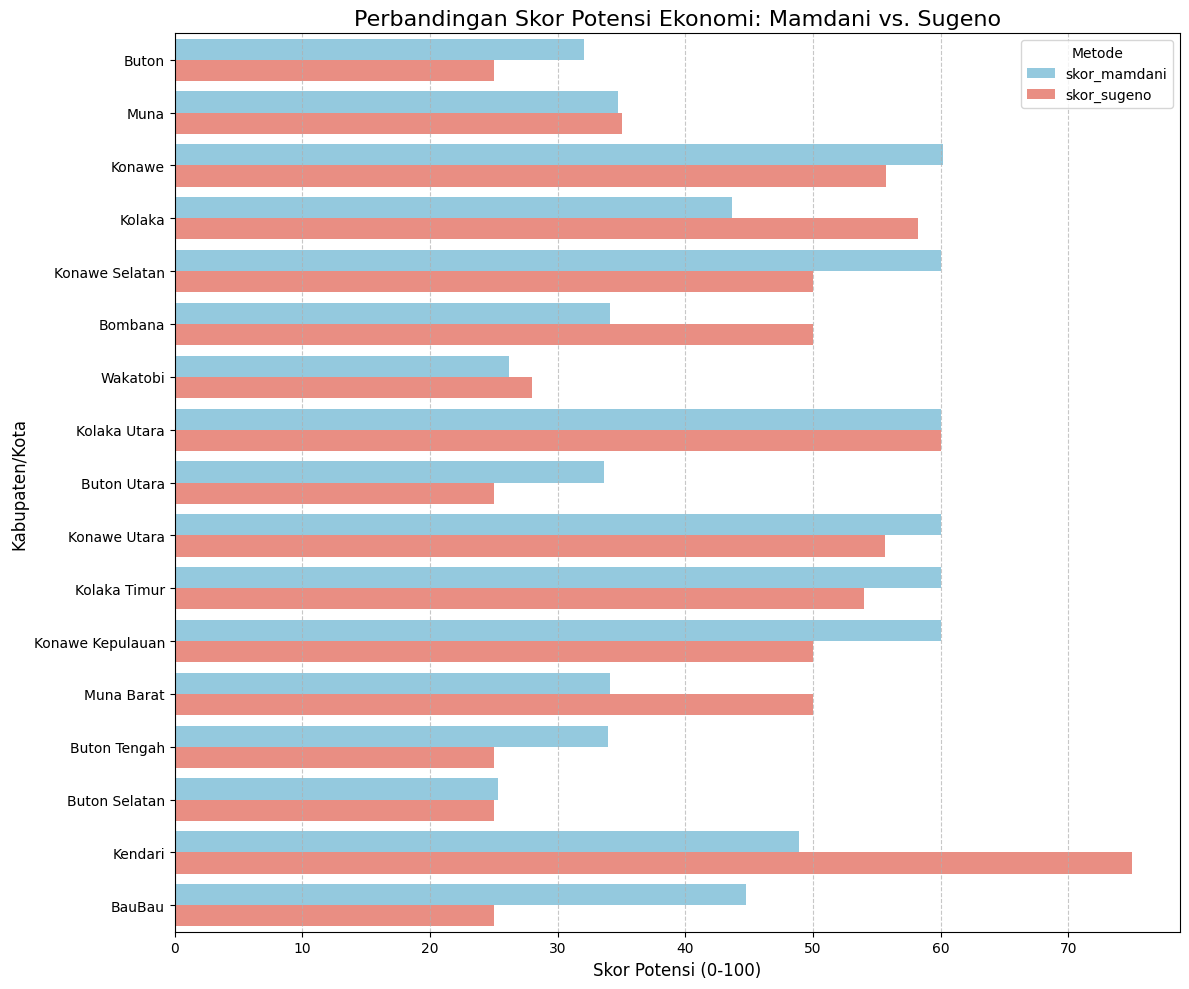

In [275]:
plot_data = tabel_perbandingan.melt(id_vars='kabupaten_kota',
                                    value_vars=['skor_mamdani', 'skor_sugeno'],
                                    var_name='metode', value_name='skor')

plt.figure(figsize=(12, 10))
sns.barplot(x='skor', y='kabupaten_kota', hue='metode', data=plot_data, palette={'skor_mamdani': 'skyblue', 'skor_sugeno': 'salmon'})
plt.title('Perbandingan Skor Potensi Ekonomi: Mamdani vs. Sugeno', fontsize=16)
plt.xlabel('Skor Potensi (0-100)', fontsize=12)
plt.ylabel('Kabupaten/Kota', fontsize=12)
plt.legend(title='Metode')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **6 Kesimpulan Akhir**

Berdasarkan analisis dan perbandingan yang telah dilakukan:

1.  **Logika Model Valid**: Kedua model, Mamdani dan Sugeno, berhasil mengklasifikasikan potensi ekonomi daerah sesuai dengan aturan yang ditetapkan. Daerah dengan IPM tinggi dan TPT rendah cenderung mendapat skor lebih tinggi, yang menunjukkan model bekerja secara logis.

2.  **Karakteristik Output yang Berbeda Secara Fundamental**:
    * **Mamdani** menghasilkan skor yang lebih **halus dan bervariasi**. Metode ini menghitung pusat massa (centroid) dari gabungan area fuzzy yang diaktifkan oleh aturan. Hasilnya adalah nilai kontinu yang merefleksikan interaksi kompleks dan tumpang tindih antara semua aturan yang relevan. Ini cocok untuk analisis yang membutuhkan gradasi dan pemahaman nuansa.
    * **Sugeno** menghasilkan skor yang lebih **tegas dan terpusat**. Metode ini bekerja seperti sistem pemungutan suara terbobot, di mana setiap aturan memberikan suara untuk nilai konstanta yang telah ditentukan (misal: 25, 50, 75). Hasil akhirnya adalah rata-rata terbobot dari suara-suara ini. Akibatnya, skor cenderung "ditarik" kuat ke arah konstanta dari aturan yang paling aktif.

3.  **Temuan Utama & Studi Kasus Divergensi**: Perbedaan cara kerja ini terlihat jelas pada kasus seperti **Kota Kendari** (Mamdani: 48.89 `Rendah`, Sugeno: 75.00 `Tinggi`) dan **Kabupaten Kolaka** (Mamdani: 43.67 `Rendah`, Sugeno: 58.25 `Sedang`). Ini **bukanlah sebuah error**, melainkan sebuah **temuan analisis yang penting**:
    * Untuk daerah-daerah ini, kemungkinan ada aturan dengan output `Tinggi` atau `Sedang` yang aktif sangat kuat.
    * Pada **Sugeno**, aktivasi kuat ini cukup untuk menarik skor akhir secara drastis ke atas.
    * Pada **Mamdani**, meskipun aturan yang sama aktif, pengaruhnya diseimbangkan oleh aturan-aturan `Rendah` lain yang mungkin juga aktif, sehingga pusat massa area gabungannya tetap rendah.

Proyek ini berhasil menunjukkan bagaimana Fuzzy Logic dapat digunakan untuk memodelkan masalah yang kompleks dan tidak pasti, serta menyoroti bahwa pilihan antara metode Mamdani dan Sugeno bukanlah soal "benar atau salah", melainkan soal **tujuan akhir dari sistem** yang dibangun.